

# Week4 Live Spring2025
### OPIM 5641 - Business Decision Modeling · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/2_MonteCarlo/Week4_Live_Spring2025.ipynb)

*Run me top to bottom - **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Week 4 Live (Spring 2025)
**Dr. Dave Wanik - OPIM 5641: Business Decision Modeling - University of Connecticut**


# Cell Phones

**[Profit Analysis 14.1 - Powell]** A consumer electronics firm produces a line
of battery rechargers for cell phones. The following distributions apply:

* Unit price triangular with a minimum of 18.95 USD, most
likely value of 24.95 USD, and maximum of 26.95 USD
* Unit cost uniform with a minimum of 12.00 USD and a
maximum of 15.00
* Quantity sold = $10,000 – 250*UnitPrice$, plus a random term
given by a normal distribution with a mean of
0 and a standard deviation of 10
* Fixed costs normal with a mean of 30,000 USD and a standard deviation of 5,000 USD

1. What is the expected profit?
2. What is the probability of a loss?
3. What is the maximum loss?

In [33]:
price = 24.95
cost = 13.5
qty = 10000 - 250*price
fixed = 30000

# profit = income - expenses
income = 24.95 * qty
expenses = (cost * qty) + fixed
profit = income - expenses
print(profit)

13080.625


In [34]:
import numpy as np
for a in np.arange(0,10,1):
  price = np.random.triangular(left=18.95,mode=24.95,right=26.95,size=1)
  cost = 13.5
  qty = 10000 - 250*price
  fixed = 30000

  # profit = income - expenses
  income = 24.95 * qty
  expenses = (cost * qty) + fixed
  profit = income - expenses
  print(profit)

[18216.31031812]
[15768.60939951]
[21496.21377925]
[11031.1523201]
[8363.04641455]
[20700.61149394]
[16154.18383506]
[8573.84394755]
[18885.57482955]
[11978.71536917]


In [43]:
import numpy as np

results = []
for a in np.arange(0,10000,1):
  price = np.random.triangular(left=18.95,mode=24.95,right=26.95,size=1)
  cost = np.random.uniform(low=12,high=15,size=1)
  qty = 10000 - 250*price + np.random.normal(loc=0, scale=10,size=1)
  fixed = np.random.normal(loc=30000, scale=5000)

  # profit = income - expenses
  income = 24.95 * qty
  expenses = (cost * qty) + fixed
  profit = income - expenses
  # print(profit)
  results.append(profit)

print(results)

[array([12500.0652529]), array([14633.30126453]), array([17596.51572144]), array([24204.53205915]), array([13899.40376123]), array([11991.43383798]), array([15677.69563571]), array([15416.73560544]), array([17432.2523744]), array([15828.57039493]), array([13858.54308029]), array([17875.74422962]), array([14549.10793758]), array([17988.50456318]), array([12276.72294449]), array([22344.30967583]), array([14811.78896577]), array([15233.56678266]), array([27660.7303333]), array([15434.04870177]), array([5784.84199684]), array([18454.02318227]), array([14536.81440735]), array([23021.72688138]), array([9455.96720302]), array([12871.22502364]), array([13434.94304895]), array([6395.50876366]), array([17498.69190612]), array([19610.86810806]), array([15711.97322276]), array([20703.41463754]), array([13028.80418323]), array([9876.31670526]), array([7852.33264094]), array([12692.03665453]), array([24479.55730837]), array([20940.03766382]), array([15603.69229533]), array([20430.45357437]), array([

In [44]:
import pandas as pd
results = pd.DataFrame(results)
results.columns = ['Profit']
results.head()

,Profit
0,12500.065253
1,14633.301265
2,17596.515721
3,24204.532059
4,13899.403761


## Expected Value?

In [45]:
results['Profit'].mean()

16882.65136320654

## Probability of a loss

In [50]:
results.shape

(10000, 1)

In [51]:
# there are 10k simulations
# I extract the first value from the tuple
results.shape[0]

10000

In [53]:
results[results['Profit']<0].shape

(92, 1)

In [54]:
results[results['Profit']<0].shape[0]

92

In [55]:
# mine has a <1% chance of a neg number
results[results['Profit']<0].shape[0]/results.shape[0] * 100


0.9199999999999999

## Min loss

In [56]:
results['Profit'].min()

-7774.138193040431

## Plot

In [ ]:
# prompt: add vertical line to hist

import matplotlib.pyplot as plt

# Assuming 'results' DataFrame is already created as in the previous code

plt.hist(results['Profit'], bins=30)  # Adjust the number of bins as needed
plt.axvline(results['Profit'].mean(), color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.title('Profit Distribution')
plt.legend()
plt.show()


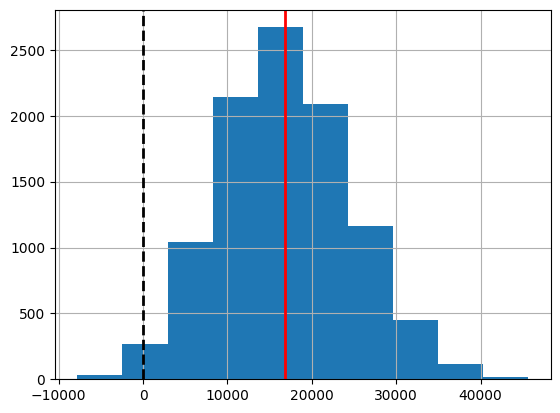

In [62]:

import matplotlib.pyplot as plt
results['Profit'].hist()
plt.axvline(x=results['Profit'].mean(), color='red', linewidth=2
            )
plt.axvline(x=0, color='black', linestyle='dashed', linewidth=2)
plt.show()

# Retirement

* 10k simulations
* We make 120K per year
* We get a 3% raise every year
* We save 10% of our salary
* S&P 500 has a mean of 7%, SD of 17% (yikes!)
* Go to work for 30 years

How much money will you have?

## Start simple!
Get it right once with some simplifying assumptions.

In [64]:
results = 0
for a in np.arange(0,5,1):
  salary = 120000
  contribution = 0.1*salary
  growth = 1.07
  results = (results + contribution)*growth
  print(results)

12840.0
26578.800000000003
41279.316000000006
57008.86812000001
73839.48888840001


## A little more complex

In [117]:
resultDF = []
myMoney = 0 # initialize a value
for a in np.arange(0,30,1):
  salary = 120000*(1 + a*0.03)
  contribution = 0.1*salary
  growth = np.random.normal(loc=1.07, scale=0.17)
  myMoney = (myMoney + contribution)*growth
  print(myMoney)
  if a == 29:
    resultDF.append(myMoney)

13566.347433591887
28034.452264737673
46040.850588367066
63213.62426029568
77905.63119610056
78880.40563919404
122606.44174288274
189450.96359799858
195688.7076029223
263963.1017871348
259290.0045835725
298915.04186834715
338858.48856811266
356300.7474244816
425702.3511495608
485891.8863434231
691917.5731932885
965875.9789602988
977980.8162495052
1229110.554574247
1381344.1171228066
997852.5469167766
876634.163836777
812754.4922119011
1207796.221966456
1228135.388197656
1153508.837669841
1322218.316472334
1140316.5042663526
1655600.5250259582


# 10k times!

In [125]:
resultDF = [] # an empty place to store 10k sims
for b in np.arange(0,10000,1):
  myMoney = 0 # at start of 30 years, your contribution is 0
  for a in np.arange(0,30,1):
    salary = 120000*(1 + a*0.03) # 3% raise!
    contribution = 0.1*salary # save 10% of your salar5y
    growth = np.random.normal(loc=1.07, scale=0.17) # growth is norm() distributed
    myMoney = (myMoney + contribution)*growth # myMoney grows 30 years

    # store myMoney when it's the last year (year = 30, count from 0)
    if a == 29:
      resultDF.append(myMoney)

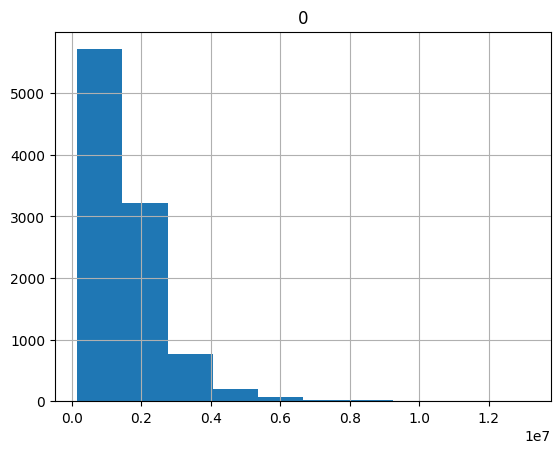

In [123]:
resultDF = pd.DataFrame(resultDF)
resultDF.hist()
plt.show()

In [124]:
resultDF.describe()

,0
count,1.000000e+04
mean,1.573299e+06
std,1.047156e+06
min,1.556150e+05
25%,8.852096e+05
50%,1.303430e+06
75%,1.961007e+06
max,1.313648e+07


# Brute Force Methods
Chairs, desks and tables

In [131]:
# initialize placeholder vars
best_profit = 0
best_c = 0
best_d = 0
best_t = 0

# initialize for loops - one loop for each dec var
for c in np.arange(0,360+1,1):
  for d in np.arange(0,300+1,1):
    for t in np.arange(0,100+1,1):
      if (4*c + 6*d + 2*t <= 1850 and
        3*c + 5*d + 7*t <= 2400 and
        3*c + 2*d + 4*t <= 1500 and
        c <= 360 and
        d <= 300 and
        t <= 100):
        # calculate profit
        current_profit = 15*c + 24*d + 18*t
        if current_profit > best_profit:
          best_profit = current_profit
          best_c = c
          best_d = d
          best_t = t
print('c:', best_c)
print('d:', best_d)
print('t:', best_t)
print('best_profit:', best_profit)

c: 0
d: 275
t: 100
best_profit: 8400


In [135]:
# add a constraint that says each table needs 2 chairs

# initialize placeholder vars
best_profit = 0
best_c = 0
best_d = 0
best_t = 0

# initialize for loops - one loop for each dec var
for c in np.arange(0,360+1,1):
  for d in np.arange(0,300+1,1):
    for t in np.arange(0,100+1,1):
      #print( c, d, t)
      if (4*c + 6*d + 2*t <= 1850 and
        3*c + 5*d + 7*t <= 2400 and
        3*c + 2*d + 4*t <= 1500 and
        c <= 360 and
        d <= 300 and
        t <= 100 and
        c >= 2*t):
        # calculate profit
        current_profit = 15*c + 24*d + 18*t

        if current_profit > best_profit:
          best_profit = current_profit
          best_c = c
          best_d = d
          best_t = t
print('c:', best_c)
print('d:', best_d)
print('t:', best_t)
print('best_profit:', best_profit)

c: 201
d: 141
t: 100
best_profit: 8199


In [141]:
products = ['c', 'd', 't']
hours = {'fab':1850,
         'assbly':2400,
         'ship':1500}

demand = {'c':360,
          'd':300,
          't':100}

fab = {'c':4,
       'd':6,
       't':2}

assbly = {'c':3,
       'd':5,
       't':7}

ship = {'c':3,
       'd':2,
       't':4}

profit = {'c':15,
       'd':24,
       't':18}

In [140]:
demand['t']

100

In [142]:
# initialize placeholder vars
best_profit = 0
best_c = 0
best_d = 0
best_t = 0

# initialize for loops - one loop for each dec var
for c in np.arange(0,demand['c']+1,1):
  for d in np.arange(0,demand['d']+1,1):
    for t in np.arange(0,demand['t']+1,1):
      if (fab['c']*c + fab['d']*d + fab['t']*t <= hours['fab'] and
        assbly['c']*c + assbly['d']*d + assbly['t']*t <= hours['assbly'] and
        ship['c']*c + ship['d']*d + ship['t']*t <= hours['ship'] and
        c <= demand['c'] and
        d <= demand['d'] and
        t <= demand['t']):
        # calculate profit
        current_profit = profit['c']*c + profit['d']*d + profit['t']*t
        if current_profit > best_profit:
          best_profit = current_profit
          best_c = c
          best_d = d
          best_t = t
print('c:', best_c)
print('d:', best_d)
print('t:', best_t)
print('best_profit:', best_profit)

c: 0
d: 275
t: 100
best_profit: 8400
